In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from collections import Counter

train_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv"
test_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)
train_df.head()

Training data: (60000, 785)
Test data: (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


****Separate X and y****

In [18]:
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X: (60000, 784)
y: (60000,)
X_test: (10000, 784)
y_test: (10000,)


**Normalize**

In [19]:
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Min pixel:", X.min())
print("Max pixel:", X.max())

Min pixel: 0.0
Max pixel: 1.0


**80/20 Split**

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (48000, 784)
y_train: (48000,)
X_val: (12000, 784)
y_val: (12000,)
X_test: (10000, 784)
y_test: (10000,)


In [21]:
print(X_train.shape)

(48000, 784)


**create the 5,000-sample subset**

In [22]:
X_subset = X_train[:5000]
y_subset = y_train[:5000]

print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)

X_subset: (5000, 784)
y_subset: (5000,)


**One-hot encoding**

In [23]:
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

In [24]:
Y_subset = one_hot(y_subset)

print(Y_subset.shape)

(5000, 10)


In [25]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

train_counts = Counter(y_train)
val_counts = Counter(y_val)

distribution = pd.DataFrame({
    "Class": range(10),
    "Class Name": class_names,
    "Training": [train_counts[i] for i in range(10)],
    "Validation": [val_counts[i] for i in range(10)],
    "Test": [Counter(y_test)[i] for i in range(10)]
})

distribution

,Class,Class Name,Training,Validation,Test
0,0,T-shirt/top,4800,1200,1000
1,1,Trouser,4800,1200,1000
2,2,Pullover,4800,1200,1000
3,3,Dress,4800,1200,1000
4,4,Coat,4800,1200,1000
5,5,Sandal,4800,1200,1000
6,6,Shirt,4800,1200,1000
7,7,Sneaker,4800,1200,1000
8,8,Bag,4800,1200,1000
9,9,Ankle boot,4800,1200,1000


**Part 1**

In [26]:
np.random.seed(42)

input_size = 784
hidden_size = 64
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 64)
b1: (1, 64)
W2: (64, 10)
b2: (1, 10)


In [27]:
def relu(x):
    return np.maximum(0, x)

In [28]:
def relu_derivative(x):
    return (x > 0).astype(np.float32)

In [29]:
def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [30]:
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

In [31]:
def forward(X, W1, b1, W2, b2):
    
    # First layer
    Z1 = X @ W1 + b1
    
    # ReLU activation
    A1 = relu(Z1)
    
    # Output layer
    Z2 = A1 @ W2 + b2
    
    # Softmax
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

In [32]:
def cross_entropy(y_true, y_pred):
    
    # Avoid log(0)
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.sum(y_true * np.log(y_pred)) / len(y_true)
    
    return loss

In [33]:
def backward(X, Y, Z1, A1, A2, W2):
    
    m = X.shape[0]
    
    # Output layer gradient
    dZ2 = A2 - Y
    
    # Gradients for W2 and b2
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    
    # Backprop into hidden layer
    dA1 = dZ2 @ W2.T
    
    # Backprop through ReLU
    dZ1 = dA1 * relu_derivative(Z1)
    
    # Gradients for W1 and b1
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    
    return dW1, db1, dW2, db2

In [34]:
def update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate):
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    return W1, b1, W2, b2

In [35]:
epochs = 20
learning_rate = 0.1

loss_history = []

for epoch in range(epochs):
    
    # Forward pass
    Z1, A1, Z2, A2 = forward(
        X_subset,
        W1, b1,
        W2, b2
    )
    
    # Calculate loss
    loss = cross_entropy(Y_subset, A2)
    loss_history.append(loss)
    
    # Backward pass
    dW1, db1, dW2, db2 = backward(
        X_subset,
        Y_subset,
        Z1,
        A1,
        A2,
        W2
    )
    
    # Update weights
    W1, b1, W2, b2 = update_parameters(
        W1, b1,
        W2, b2,
        dW1, db1,
        dW2, db2,
        learning_rate
    )
    
    print(f"Epoch {epoch + 1:02d}/{epochs} - Loss: {loss:.4f}")

Epoch 01/20 - Loss: 2.6527
Epoch 02/20 - Loss: 2.2599
Epoch 03/20 - Loss: 2.1098
Epoch 04/20 - Loss: 1.9927
Epoch 05/20 - Loss: 1.8868
Epoch 06/20 - Loss: 1.7918
Epoch 07/20 - Loss: 1.7088
Epoch 08/20 - Loss: 1.6414
Epoch 09/20 - Loss: 1.5935
Epoch 10/20 - Loss: 1.5446
Epoch 11/20 - Loss: 1.5114
Epoch 12/20 - Loss: 1.4182
Epoch 13/20 - Loss: 1.3715
Epoch 14/20 - Loss: 1.3056
Epoch 15/20 - Loss: 1.2724
Epoch 16/20 - Loss: 1.2244
Epoch 17/20 - Loss: 1.2018
Epoch 18/20 - Loss: 1.1612
Epoch 19/20 - Loss: 1.1447
Epoch 20/20 - Loss: 1.1097


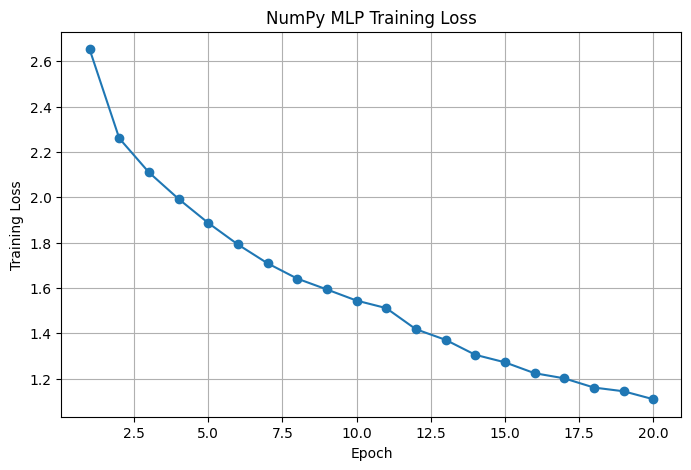

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NumPy MLP Training Loss")
plt.grid(True)

plt.show()

In [37]:
np.random.seed(123)

W1_test = np.random.randn(784, 64).astype(np.float32) * np.sqrt(2 / 784)
b1_test = np.zeros((1, 64), dtype=np.float32)

W2_test = np.random.randn(64, 10).astype(np.float32) * np.sqrt(2 / 64)
b2_test = np.zeros((1, 10), dtype=np.float32)

In [38]:
X_batch = X_train[:32].astype(np.float32)
y_batch = y_train[:32]

Y_batch = one_hot(y_batch).astype(np.float32)

In [39]:
Z1_np, A1_np, Z2_np, A2_np = forward(
    X_batch,
    W1_test,
    b1_test,
    W2_test,
    b2_test
)

np_loss = cross_entropy(Y_batch, A2_np)

dW1_np, db1_np, dW2_np, db2_np = backward(
    X_batch,
    Y_batch,
    Z1_np,
    A1_np,
    A2_np,
    W2_test
)

print("NumPy loss:", np_loss)

NumPy loss: 2.445712337555798


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [41]:
class MLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

In [42]:
torch_model = MLP()

# Disable unnecessary gradient tracking during weight copying
with torch.no_grad():
    
    torch_model.fc1.weight.copy_(
        torch.tensor(W1_test.T)
    )
    
    torch_model.fc1.bias.copy_(
        torch.tensor(b1_test.flatten())
    )
    
    torch_model.fc2.weight.copy_(
        torch.tensor(W2_test.T)
    )
    
    torch_model.fc2.bias.copy_(
        torch.tensor(b2_test.flatten())
    )

In [43]:
X_tensor = torch.tensor(X_batch)
y_tensor = torch.tensor(y_batch, dtype=torch.long)

criterion = nn.CrossEntropyLoss()

# Forward
logits = torch_model(X_tensor)

# Loss
torch_loss = criterion(logits, y_tensor)

# Backward
torch_loss.backward()

print("PyTorch loss:", torch_loss.item())

PyTorch loss: 2.4457123279571533


In [44]:
dW1_torch = torch_model.fc1.weight.grad.detach().numpy().T
dW2_torch = torch_model.fc2.weight.grad.detach().numpy().T

db1_torch = torch_model.fc1.bias.grad.detach().numpy().reshape(1, -1)
db2_torch = torch_model.fc2.bias.grad.detach().numpy().reshape(1, -1)

In [45]:
diff_W1 = np.max(np.abs(dW1_np - dW1_torch))
diff_W2 = np.max(np.abs(dW2_np - dW2_torch))

diff_b1 = np.max(np.abs(db1_np - db1_torch))
diff_b2 = np.max(np.abs(db2_np - db2_torch))

print(f"Maximum absolute difference - W1: {diff_W1:.10f}")
print(f"Maximum absolute difference - W2: {diff_W2:.10f}")
print(f"Maximum absolute difference - b1: {diff_b1:.10f}")
print(f"Maximum absolute difference - b2: {diff_b2:.10f}")

Maximum absolute difference - W1: 0.0000000205
Maximum absolute difference - W2: 0.0000000389
Maximum absolute difference - b1: 0.0000000098
Maximum absolute difference - b2: 0.0000000139


In [46]:

print("GRADIENT VERIFICATION")


print(f"NumPy Loss:   {np_loss:.10f}")
print(f"PyTorch Loss: {torch_loss.item():.10f}")

print()

print(f"W1 max absolute difference: "
      f"{diff_W1:.10e}")

print(f"W2 max absolute difference: "
      f"{diff_W2:.10e}")

print(f"b1 max absolute difference: "
      f"{diff_b1:.10e}")

print(f"b2 max absolute difference: "
      f"{diff_b2:.10e}")

GRADIENT VERIFICATION
NumPy Loss:   2.4457123376
PyTorch Loss: 2.4457123280

W1 max absolute difference: 2.0545927668e-08
W2 max absolute difference: 3.8938829383e-08
b1 max absolute difference: 9.8326422560e-09
b2 max absolute difference: 1.3948979416e-08


**PART 2**

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_val_tensor.shape)
print(y_val_tensor.shape)

torch.Size([48000, 784])
torch.Size([48000])
torch.Size([12000, 784])
torch.Size([12000])


In [48]:
class MLP(nn.Module):

    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):

        x = self.fc1(x)
        x = self.activation(x)

        x = self.fc2(x)
        x = self.activation(x)

        x = self.fc3(x)

        return x

In [49]:
torch.manual_seed(123)

initial_model = MLP(nn.ReLU())

initial_state = {
    key: value.clone()
    for key, value in initial_model.state_dict().items()
}

In [50]:
def train_model(model, epochs=20, batch_size=128, learning_rate=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    gradient_history = []

    # DataLoader
    train_dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            # Record first hidden layer gradient
            gradient_history.append(
                model.fc1.weight.grad.abs().mean().item()
            )

            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)

        average_train_loss = (
            total_train_loss / len(train_loader.dataset)
        )

        # Validation
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val_tensor)

            val_loss = criterion(
                val_outputs,
                y_val_tensor
            )

        train_losses.append(average_train_loss)
        val_losses.append(val_loss.item())

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f}"
        )

    return train_losses, val_losses, gradient_history

In [51]:
def train_model(model, epochs=20, batch_size=128, learning_rate=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    epoch_gradient_means = []

    train_dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0
        batch_gradients = []

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            # Mean absolute gradient of first hidden layer
            mean_abs_gradient = (
                model.fc1.weight.grad.abs().mean().item()
            )

            batch_gradients.append(mean_abs_gradient)

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

        average_train_loss = (
            total_train_loss / len(train_loader.dataset)
        )

        # Average gradient across all batches in this epoch
        epoch_gradient = np.mean(batch_gradients)

        epoch_gradient_means.append(epoch_gradient)

        # Validation
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val_tensor)

            val_loss = criterion(
                val_outputs,
                y_val_tensor
            )

        train_losses.append(average_train_loss)
        val_losses.append(val_loss.item())

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Grad: {epoch_gradient:.6f}"
        )

    return (
        train_losses,
        val_losses,
        epoch_gradient_means
    )

In [52]:
models = {}

activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

In [53]:
results = {}

for name, activation in activations.items():

    
    print(f"Training {name} model")
    

    model = MLP(activation)

    # Use identical initial weights
    model.load_state_dict(initial_state)

    train_losses, val_losses, gradients = train_model(
        model,
        epochs=20,
        batch_size=128,
        learning_rate=0.001
    )

    models[name] = model

    results[name] = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "gradients": gradients
    }

Training Sigmoid model
Epoch 01/20 | Train Loss: 1.1379 | Val Loss: 0.6397 | Grad: 0.000102
Epoch 02/20 | Train Loss: 0.5313 | Val Loss: 0.4674 | Grad: 0.000203
Epoch 03/20 | Train Loss: 0.4379 | Val Loss: 0.4241 | Grad: 0.000259
Epoch 04/20 | Train Loss: 0.3965 | Val Loss: 0.3870 | Grad: 0.000292
Epoch 05/20 | Train Loss: 0.3697 | Val Loss: 0.3786 | Grad: 0.000308
Epoch 06/20 | Train Loss: 0.3508 | Val Loss: 0.3662 | Grad: 0.000326
Epoch 07/20 | Train Loss: 0.3377 | Val Loss: 0.3686 | Grad: 0.000345
Epoch 08/20 | Train Loss: 0.3240 | Val Loss: 0.3510 | Grad: 0.000357
Epoch 09/20 | Train Loss: 0.3123 | Val Loss: 0.3570 | Grad: 0.000363
Epoch 10/20 | Train Loss: 0.3040 | Val Loss: 0.3388 | Grad: 0.000382
Epoch 11/20 | Train Loss: 0.2937 | Val Loss: 0.3318 | Grad: 0.000384
Epoch 12/20 | Train Loss: 0.2861 | Val Loss: 0.3289 | Grad: 0.000396
Epoch 13/20 | Train Loss: 0.2809 | Val Loss: 0.3234 | Grad: 0.000417
Epoch 14/20 | Train Loss: 0.2725 | Val Loss: 0.3259 | Grad: 0.000416
Epoch 15/20

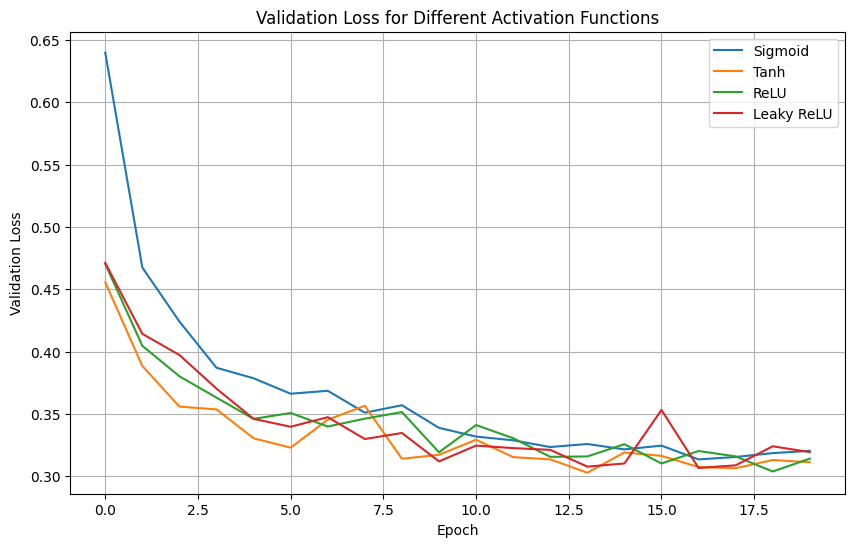

In [54]:
plt.figure(figsize=(10, 6))

for name in results:

    plt.plot(
        results[name]["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
sigmoid_gradients = results["Sigmoid"]["gradients"]
relu_gradients = results["ReLU"]["gradients"]

print("SIGMOID")
print("Epoch 1 gradient:",
      sigmoid_gradients[0])
print("Final epoch gradient:",
      sigmoid_gradients[-1])

print()

print("RELU")
print("Epoch 1 gradient:",
      relu_gradients[0])
print("Final epoch gradient:",
      relu_gradients[-1])

SIGMOID
Epoch 1 gradient: 0.00010152550021302886
Final epoch gradient: 0.00044565269250112274

RELU
Epoch 1 gradient: 0.0008620546555612236
Final epoch gradient: 0.0010133709334768355


In [56]:
gradient_table = pd.DataFrame({
    "Activation": ["Sigmoid", "ReLU"],
    "Epoch 1 Mean |Gradient|": [
        sigmoid_gradients[0],
        relu_gradients[0]
    ],
    "Final Epoch Mean |Gradient|": [
        sigmoid_gradients[-1],
        relu_gradients[-1]
    ]
})

gradient_table

,Activation,Epoch 1 Mean |Gradient|,Final Epoch Mean |Gradient|
0,Sigmoid,0.000102,0.000446
1,ReLU,0.000862,0.001013


In [57]:
relu_model = models["ReLU"]

relu_model.eval()

validation_batch = X_val_tensor[:128]

with torch.no_grad():

    first_hidden_output = relu_model.fc1(
        validation_batch
    )

    first_hidden_output = torch.relu(
        first_hidden_output
    )

print(first_hidden_output.shape)

torch.Size([128, 128])


In [58]:
zero_for_every_sample = (
    first_hidden_output == 0
).all(dim=0)

dead_units = zero_for_every_sample.sum().item()

total_units = first_hidden_output.shape[1]

dead_percentage = (
    dead_units / total_units
) * 100

print("Dead units:", dead_units)
print("Total hidden units:", total_units)
print(f"Dead-unit percentage: {dead_percentage:.2f}%")

Dead units: 13
Total hidden units: 128
Dead-unit percentage: 10.16%


In [157]:

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

#  ReLU baseline
relu_model.eval()

with torch.no_grad():
    test_outputs = relu_model(X_test_tensor)
    predictions = torch.argmax(test_outputs, dim=1)

baseline_accuracy = (
    (predictions == y_test_tensor).float().mean().item()
)

print(f"Part 2 ReLU Baseline Test Accuracy: {baseline_accuracy * 100:.2f}%")

Part 2 ReLU Baseline Test Accuracy: 89.30%


**PART 3**

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

In [60]:
class ClassificationMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

In [61]:
X_train
y_train
X_val
y_val
X_test
y_test

array([0, 1, 2, ..., 8, 8, 1])

In [62]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [63]:
num_classes = 10

y_train_onehot = torch.zeros(len(y_train), num_classes)
y_train_onehot.scatter_(1, y_train_tensor.unsqueeze(1), 1)

y_test_onehot = torch.zeros(len(y_test), num_classes)
y_test_onehot.scatter_(1, y_test_tensor.unsqueeze(1), 1)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])

In [64]:
def train_classification_model(loss_type, epochs=20, batch_size=128, lr=0.001):
    
    torch.manual_seed(42)
    
    model = ClassificationMLP()
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    if loss_type == "CE":
        criterion = nn.CrossEntropyLoss()
    elif loss_type == "MSE":
        criterion = nn.MSELoss()
    
    dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor,
        y_train_onehot
    )
    
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    train_losses = []
    
    for epoch in range(epochs):
        
        model.train()
        total_loss = 0
        
        for X_batch, y_batch, y_onehot_batch in loader:
            
            optimizer.zero_grad()
            
            logits = model(X_batch)
            
            if loss_type == "CE":
                loss = criterion(logits, y_batch)
            
            else:
                # Convert logits to probabilities for MSE
                probabilities = torch.softmax(logits, dim=1)
                loss = criterion(probabilities, y_onehot_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
        
        average_loss = total_loss / len(loader.dataset)
        train_losses.append(average_loss)
        
        print(
            f"{loss_type} | "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Loss: {average_loss:.4f}"
        )
    
    return model, train_losses

In [65]:
ce_model, ce_losses = train_classification_model(
    loss_type="CE",
    epochs=20,
    batch_size=128,
    lr=0.001
)

CE | Epoch 01/20 | Loss: 0.6566
CE | Epoch 02/20 | Loss: 0.4300
CE | Epoch 03/20 | Loss: 0.3847
CE | Epoch 04/20 | Loss: 0.3618
CE | Epoch 05/20 | Loss: 0.3407
CE | Epoch 06/20 | Loss: 0.3232
CE | Epoch 07/20 | Loss: 0.3092
CE | Epoch 08/20 | Loss: 0.2965
CE | Epoch 09/20 | Loss: 0.2882
CE | Epoch 10/20 | Loss: 0.2794
CE | Epoch 11/20 | Loss: 0.2711
CE | Epoch 12/20 | Loss: 0.2630
CE | Epoch 13/20 | Loss: 0.2538
CE | Epoch 14/20 | Loss: 0.2468
CE | Epoch 15/20 | Loss: 0.2391
CE | Epoch 16/20 | Loss: 0.2331
CE | Epoch 17/20 | Loss: 0.2237
CE | Epoch 18/20 | Loss: 0.2163
CE | Epoch 19/20 | Loss: 0.2100
CE | Epoch 20/20 | Loss: 0.2093


In [66]:
mse_model, mse_losses = train_classification_model(
    loss_type="MSE",
    epochs=20,
    batch_size=128,
    lr=0.001
)

MSE | Epoch 01/20 | Loss: 0.0321
MSE | Epoch 02/20 | Loss: 0.0221
MSE | Epoch 03/20 | Loss: 0.0200
MSE | Epoch 04/20 | Loss: 0.0189
MSE | Epoch 05/20 | Loss: 0.0179
MSE | Epoch 06/20 | Loss: 0.0171
MSE | Epoch 07/20 | Loss: 0.0165
MSE | Epoch 08/20 | Loss: 0.0159
MSE | Epoch 09/20 | Loss: 0.0155
MSE | Epoch 10/20 | Loss: 0.0152
MSE | Epoch 11/20 | Loss: 0.0148
MSE | Epoch 12/20 | Loss: 0.0145
MSE | Epoch 13/20 | Loss: 0.0139
MSE | Epoch 14/20 | Loss: 0.0139
MSE | Epoch 15/20 | Loss: 0.0134
MSE | Epoch 16/20 | Loss: 0.0132
MSE | Epoch 17/20 | Loss: 0.0127
MSE | Epoch 18/20 | Loss: 0.0124
MSE | Epoch 19/20 | Loss: 0.0122
MSE | Epoch 20/20 | Loss: 0.0121


In [67]:
def get_test_accuracy(model):
    
    model.eval()
    
    with torch.no_grad():
        logits = model(X_test_tensor)
        predictions = torch.argmax(logits, dim=1)
    
    accuracy = (predictions == y_test_tensor).float().mean().item()
    
    return accuracy

In [68]:
ce_accuracy = get_test_accuracy(ce_model)
mse_accuracy = get_test_accuracy(mse_model)

print(f"Cross-Entropy Test Accuracy: {ce_accuracy * 100:.2f}%")
print(f"MSE Test Accuracy:           {mse_accuracy * 100:.2f}%")

Cross-Entropy Test Accuracy: 89.44%
MSE Test Accuracy:           88.45%


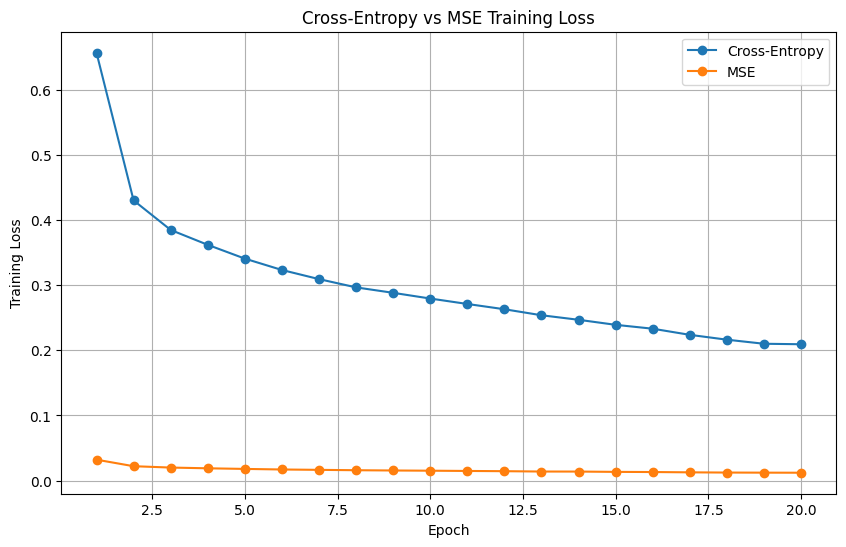

In [69]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 21),
    ce_losses,
    marker="o",
    label="Cross-Entropy"
)

plt.plot(
    range(1, 21),
    mse_losses,
    marker="o",
    label="MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Cross-Entropy vs MSE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [71]:
housing = fetch_california_housing()

X_reg = housing.data
y_reg = housing.target

print("Features:", X_reg.shape)
print("Target:", y_reg.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

In [72]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_reg, y_reg = make_regression(
    n_samples=5000,
    n_features=8,
    n_informative=6,
    noise=10,
    random_state=42
)

print("Features:", X_reg.shape)
print("Target:", y_reg.shape)

Features: (5000, 8)
Target: (5000,)


In [73]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [74]:
scaler = StandardScaler()

X_reg_train = scaler.fit_transform(X_reg_train)
X_reg_test = scaler.transform(X_reg_test)

In [75]:
X_reg_train_tensor = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train_tensor = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).view(-1, 1)

X_reg_test_tensor = torch.tensor(
    X_reg_test,
    dtype=torch.float32
)

y_reg_test_tensor = torch.tensor(
    y_reg_test,
    dtype=torch.float32
).view(-1, 1)

In [76]:
class RegressionMLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(8, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        
        x = torch.relu(
            self.fc1(x)
        )
        
        x = torch.relu(
            self.fc2(x)
        )
        
        x = self.fc3(x)
        
        return x

In [77]:
reg_model = RegressionMLP()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

dataset = torch.utils.data.TensorDataset(
    X_reg_train_tensor,
    y_reg_train_tensor
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

regression_losses = []

epochs = 30

for epoch in range(epochs):
    
    reg_model.train()
    
    total_loss = 0
    
    for X_batch, y_batch in loader:
        
        optimizer.zero_grad()
        
        predictions = reg_model(
            X_batch
        )
        
        loss = criterion(
            predictions,
            y_batch
        )
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += (
            loss.item()
            * X_batch.size(0)
        )
    
    average_loss = (
        total_loss
        / len(loader.dataset)
    )
    
    regression_losses.append(
        average_loss
    )
    
    print(
        f"Epoch {epoch+1:02d}/{epochs} "
        f"- MSE Loss: {average_loss:.4f}"
    )

Epoch 01/30 - MSE Loss: 23953.9966
Epoch 02/30 - MSE Loss: 23895.5479
Epoch 03/30 - MSE Loss: 23708.6804
Epoch 04/30 - MSE Loss: 23250.9850
Epoch 05/30 - MSE Loss: 22380.4579
Epoch 06/30 - MSE Loss: 20932.0088
Epoch 07/30 - MSE Loss: 18872.0401
Epoch 08/30 - MSE Loss: 16207.3284
Epoch 09/30 - MSE Loss: 13103.1435
Epoch 10/30 - MSE Loss: 9899.8805
Epoch 11/30 - MSE Loss: 6927.9405
Epoch 12/30 - MSE Loss: 4528.2213
Epoch 13/30 - MSE Loss: 2800.9372
Epoch 14/30 - MSE Loss: 1703.2166
Epoch 15/30 - MSE Loss: 1077.1022
Epoch 16/30 - MSE Loss: 738.6686
Epoch 17/30 - MSE Loss: 550.9519
Epoch 18/30 - MSE Loss: 441.7845
Epoch 19/30 - MSE Loss: 385.8877
Epoch 20/30 - MSE Loss: 359.2007
Epoch 21/30 - MSE Loss: 344.5942
Epoch 22/30 - MSE Loss: 335.4697
Epoch 23/30 - MSE Loss: 327.9043
Epoch 24/30 - MSE Loss: 321.3420
Epoch 25/30 - MSE Loss: 316.0025
Epoch 26/30 - MSE Loss: 309.1968
Epoch 27/30 - MSE Loss: 303.1893
Epoch 28/30 - MSE Loss: 297.6810
Epoch 29/30 - MSE Loss: 292.0042
Epoch 30/30 - MSE L

In [78]:
reg_model.eval()

with torch.no_grad():
    
    predictions = reg_model(
        X_reg_test_tensor
    ).numpy()

actual = y_reg_test_tensor.numpy()

In [79]:
mse = mean_squared_error(
    actual,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    actual,
    predictions
)

print("\nRegression Test Results")


print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


Regression Test Results
MSE:  286.1270
RMSE: 16.9153
MAE:  13.3950


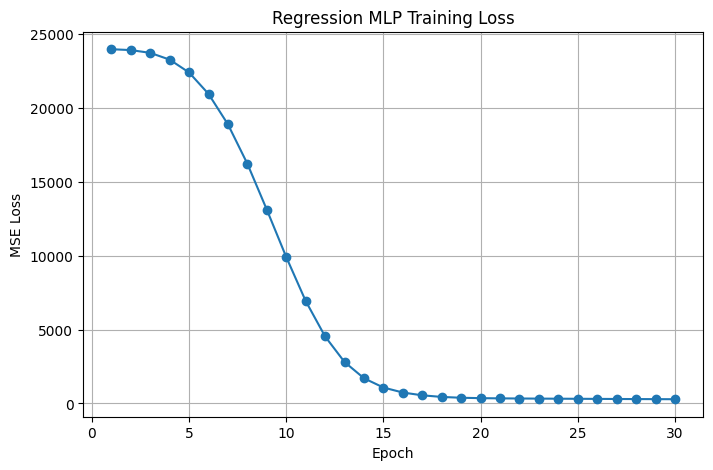

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    regression_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Regression MLP Training Loss"
)

plt.grid(True)

plt.show()

**Part 4**

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

In [83]:
class OptimizerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

In [84]:
def train_with_optimizer(
    optimizer_name,
    learning_rate,
    epochs=20,
    batch_size=128
):
    
    # Same random initialization for fair comparison
    torch.manual_seed(42)
    
    model = OptimizerMLP()
    
    # Select optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate
        )
        
    elif optimizer_name == "SGD + momentum":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )
        
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )
        
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )
    
    criterion = nn.CrossEntropyLoss()
    
    # DataLoader
    dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )
    
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    train_losses = []
    val_accuracies = []
    
    epoch_85 = None
    
    # Start timer
    start_time = time.time()
    
    for epoch in range(epochs):
        
        model.train()
        
        total_loss = 0
        
        for X_batch, y_batch in loader:
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            
            optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
        
        # Average training loss
        average_loss = total_loss / len(loader.dataset)
        train_losses.append(average_loss)
        
        # Validation accuracy
        model.eval()
        
        with torch.no_grad():
            
            val_outputs = model(X_val_tensor)
            
            predictions = torch.argmax(
                val_outputs,
                dim=1
            )
            
            val_accuracy = (
                predictions == y_val_tensor
            ).float().mean().item() * 100
        
        val_accuracies.append(val_accuracy)
        
        # Record first epoch reaching 85%
        if epoch_85 is None and val_accuracy >= 85:
            epoch_85 = epoch + 1
        
        print(
            f"{optimizer_name:18s} | "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Loss: {average_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )
    
    # End timer
    wall_clock_time = time.time() - start_time
    
    final_accuracy = val_accuracies[-1]
    
    return {
        "model": model,
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "epoch_85": epoch_85,
        "final_accuracy": final_accuracy,
        "time": wall_clock_time
    }

In [85]:
same_lr = 0.001
same_lr_results = {}

optimizers = [
    "SGD",
    "SGD + momentum",
    "RMSProp",
    "Adam"
]

for optimizer_name in optimizers:
    
    
    print(f"Training with {optimizer_name}")
    
    same_lr_results[optimizer_name] = train_with_optimizer(
        optimizer_name=optimizer_name,
        learning_rate=same_lr,
        epochs=20,
        batch_size=128
    )

Training with SGD
SGD                | Epoch 01/20 | Loss: 2.2917 | Val Acc: 17.97%
SGD                | Epoch 02/20 | Loss: 2.2577 | Val Acc: 19.57%
SGD                | Epoch 03/20 | Loss: 2.2196 | Val Acc: 22.27%
SGD                | Epoch 04/20 | Loss: 2.1671 | Val Acc: 31.74%
SGD                | Epoch 05/20 | Loss: 2.0972 | Val Acc: 39.79%
SGD                | Epoch 06/20 | Loss: 2.0049 | Val Acc: 47.22%
SGD                | Epoch 07/20 | Loss: 1.8904 | Val Acc: 49.34%
SGD                | Epoch 08/20 | Loss: 1.7626 | Val Acc: 50.57%
SGD                | Epoch 09/20 | Loss: 1.6347 | Val Acc: 51.61%
SGD                | Epoch 10/20 | Loss: 1.5162 | Val Acc: 55.59%
SGD                | Epoch 11/20 | Loss: 1.4111 | Val Acc: 60.21%
SGD                | Epoch 12/20 | Loss: 1.3205 | Val Acc: 61.86%
SGD                | Epoch 13/20 | Loss: 1.2427 | Val Acc: 62.92%
SGD                | Epoch 14/20 | Loss: 1.1759 | Val Acc: 63.65%
SGD                | Epoch 15/20 | Loss: 1.1183 | Val Acc:

In [86]:
print("\nSAME LEARNING RATE RESULTS")


for name, result in same_lr_results.items():
    
    epoch_85 = result["epoch_85"]
    
    if epoch_85 is None:
        epoch_85_display = "Not reached"
    else:
        epoch_85_display = epoch_85
    
    print(
        f"{name:18s} | "
        f"85% Epoch: {epoch_85_display} | "
        f"Final Val Acc: {result['final_accuracy']:.2f}% | "
        f"Time: {result['time']:.2f}s"
    )


SAME LEARNING RATE RESULTS
SGD                | 85% Epoch: Not reached | Final Val Acc: 67.68% | Time: 17.84s
SGD + momentum     | 85% Epoch: Not reached | Final Val Acc: 84.51% | Time: 18.79s
RMSProp            | 85% Epoch: 2 | Final Val Acc: 88.87% | Time: 21.75s
Adam               | 85% Epoch: 2 | Final Val Acc: 89.08% | Time: 23.35s


**round 2**

In [91]:
tuned_learning_rates = {
    "SGD": 0.01,
    "SGD + momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

In [92]:
tuned_results = {}

for optimizer_name in optimizers:
    
    lr = tuned_learning_rates[optimizer_name]
    
    
    print(f"Training with {optimizer_name} | LR = {lr}")
    
    tuned_results[optimizer_name] = train_with_optimizer(
        optimizer_name=optimizer_name,
        learning_rate=lr,
        epochs=20,
        batch_size=128
    )

Training with SGD | LR = 0.01
SGD                | Epoch 01/20 | Loss: 1.9878 | Val Acc: 55.77%
SGD                | Epoch 02/20 | Loss: 1.1284 | Val Acc: 67.77%
SGD                | Epoch 03/20 | Loss: 0.8308 | Val Acc: 72.09%
SGD                | Epoch 04/20 | Loss: 0.7276 | Val Acc: 75.50%
SGD                | Epoch 05/20 | Loss: 0.6657 | Val Acc: 78.03%
SGD                | Epoch 06/20 | Loss: 0.6197 | Val Acc: 79.39%
SGD                | Epoch 07/20 | Loss: 0.5841 | Val Acc: 80.19%
SGD                | Epoch 08/20 | Loss: 0.5566 | Val Acc: 81.21%
SGD                | Epoch 09/20 | Loss: 0.5357 | Val Acc: 81.05%
SGD                | Epoch 10/20 | Loss: 0.5194 | Val Acc: 81.62%
SGD                | Epoch 11/20 | Loss: 0.5060 | Val Acc: 82.52%
SGD                | Epoch 12/20 | Loss: 0.4960 | Val Acc: 82.85%
SGD                | Epoch 13/20 | Loss: 0.4858 | Val Acc: 83.09%
SGD                | Epoch 14/20 | Loss: 0.4771 | Val Acc: 83.17%
SGD                | Epoch 15/20 | Loss: 0.470

In [94]:
import pandas as pd

results_table = []

for optimizer_name in optimizers:
    
    result = tuned_results[optimizer_name]
    
    epoch_85 = result["epoch_85"]
    
    if epoch_85 is None:
        epoch_85 = "Not reached"
    
    results_table.append({
        "Optimiser": optimizer_name,
        "Learning rate": tuned_learning_rates[optimizer_name],
        "Epochs to reach 85%": epoch_85,
        "Final validation accuracy (%)": round(
            result["final_accuracy"], 2
        ),
        "Wall-clock time (s)": round(
            result["time"], 2
        )
    })

results_df = pd.DataFrame(results_table)

results_df

,Optimiser,Learning rate,Epochs to reach 85%,Final validation accuracy (%),Wall-clock time (s)
0,SGD,0.010,Not reached,84.57,18.07
1,SGD + momentum,0.010,4,88.13,19.03
2,RMSProp,0.001,2,88.87,22.15
3,Adam,0.001,2,89.08,23.78


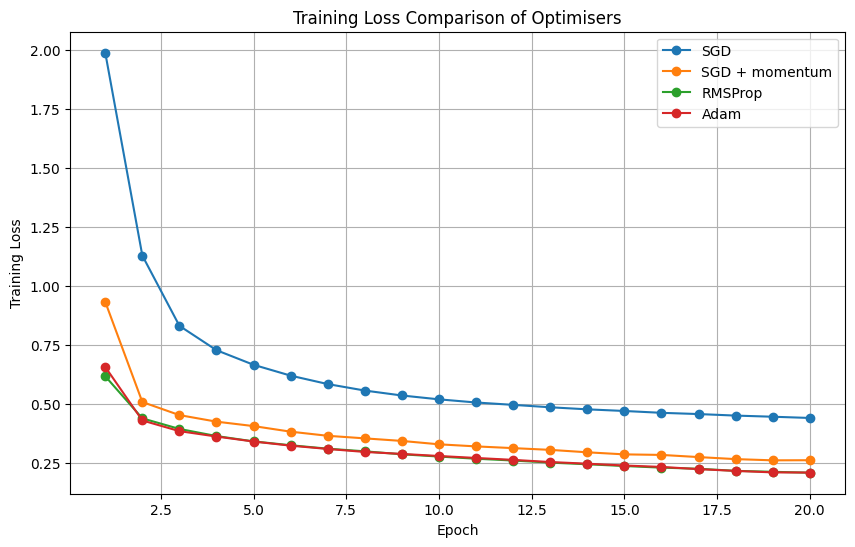

In [95]:
plt.figure(figsize=(10, 6))

for optimizer_name in optimizers:
    
    plt.plot(
        range(1, 21),
        tuned_results[optimizer_name]["train_losses"],
        marker="o",
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison of Optimisers")
plt.legend()
plt.grid(True)

plt.show()

In [96]:
best_optimizer = max(
    tuned_results,
    key=lambda name: tuned_results[name]["final_accuracy"]
)

print("Best optimizer based on final validation accuracy:")
print(best_optimizer)

print(
    f"Final validation accuracy: "
    f"{tuned_results[best_optimizer]['final_accuracy']:.2f}%"
)

Best optimizer based on final validation accuracy:
Adam
Final validation accuracy: 89.08%


**part 5**

In [97]:

X_overfit = X_train[:2000]
y_overfit = y_train[:2000]

X_overfit_tensor = torch.tensor(
    X_overfit,
    dtype=torch.float32
)

y_overfit_tensor = torch.tensor(
    y_overfit,
    dtype=torch.long
)

print("Overfitting training set:")
print("X shape:", X_overfit_tensor.shape)
print("y shape:", y_overfit_tensor.shape)

Overfitting training set:
X shape: torch.Size([2000, 784])
y shape: torch.Size([2000])


In [98]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        
        return x

In [99]:
torch.manual_seed(42)

overfit_model = OverfitMLP()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    overfit_model.parameters(),
    lr=0.001
)

dataset = torch.utils.data.TensorDataset(
    X_overfit_tensor,
    y_overfit_tensor
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 100

for epoch in range(epochs):
    
    
    overfit_model.train()
    
    total_loss = 0
    
    for X_batch, y_batch in loader:
        
        optimizer.zero_grad()
        
        outputs = overfit_model(X_batch)
        
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
    
    average_train_loss = (
        total_loss / len(loader.dataset)
    )
    
    
    overfit_model.eval()
    
    with torch.no_grad():
        
        train_outputs = overfit_model(
            X_overfit_tensor
        )
        
        train_predictions = torch.argmax(
            train_outputs,
            dim=1
        )
        
        train_accuracy = (
            train_predictions == y_overfit_tensor
        ).float().mean().item() * 100
        
        
        val_outputs = overfit_model(
            X_val_tensor
        )
        
        val_loss = criterion(
            val_outputs,
            y_val_tensor
        ).item()
        
        val_predictions = torch.argmax(
            val_outputs,
            dim=1
        )
        
        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item() * 100
    
    train_losses.append(average_train_loss)
    val_losses.append(val_loss)
    
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    
    print(
        f"Epoch {epoch+1:03d}/{epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch 001/100 | Train Loss: 1.6557 | Train Acc: 50.60% | Val Loss: 1.2130 | Val Acc: 50.70%
Epoch 002/100 | Train Loss: 0.9527 | Train Acc: 70.00% | Val Loss: 0.8397 | Val Acc: 68.57%
Epoch 003/100 | Train Loss: 0.7711 | Train Acc: 72.15% | Val Loss: 0.7642 | Val Acc: 72.12%
Epoch 004/100 | Train Loss: 0.6914 | Train Acc: 79.15% | Val Loss: 0.6631 | Val Acc: 76.39%
Epoch 005/100 | Train Loss: 0.5849 | Train Acc: 80.95% | Val Loss: 0.6037 | Val Acc: 77.17%
Epoch 006/100 | Train Loss: 0.5339 | Train Acc: 79.85% | Val Loss: 0.6647 | Val Acc: 75.52%
Epoch 007/100 | Train Loss: 0.4849 | Train Acc: 85.05% | Val Loss: 0.5480 | Val Acc: 80.24%
Epoch 008/100 | Train Loss: 0.4326 | Train Acc: 84.10% | Val Loss: 0.5915 | Val Acc: 78.91%
Epoch 009/100 | Train Loss: 0.3922 | Train Acc: 86.55% | Val Loss: 0.5824 | Val Acc: 79.95%
Epoch 010/100 | Train Loss: 0.3685 | Train Acc: 87.15% | Val Loss: 0.5615 | Val Acc: 80.58%
Epoch 011/100 | Train Loss: 0.3708 | Train Acc: 86.60% | Val Loss: 0.5927 | Val 

In [100]:
separation_epoch = None

for i in range(1, len(train_losses)):
    
    training_loss_decreasing = (
        train_losses[i] < train_losses[i-1]
    )
    
    validation_loss_increasing = (
        val_losses[i] > val_losses[i-1]
    )
    
    if training_loss_decreasing and validation_loss_increasing:
        separation_epoch = i + 1
        break

print(
    "Epoch where training and validation losses "
    f"start separating: {separation_epoch}"
)

Epoch where training and validation losses start separating: 6


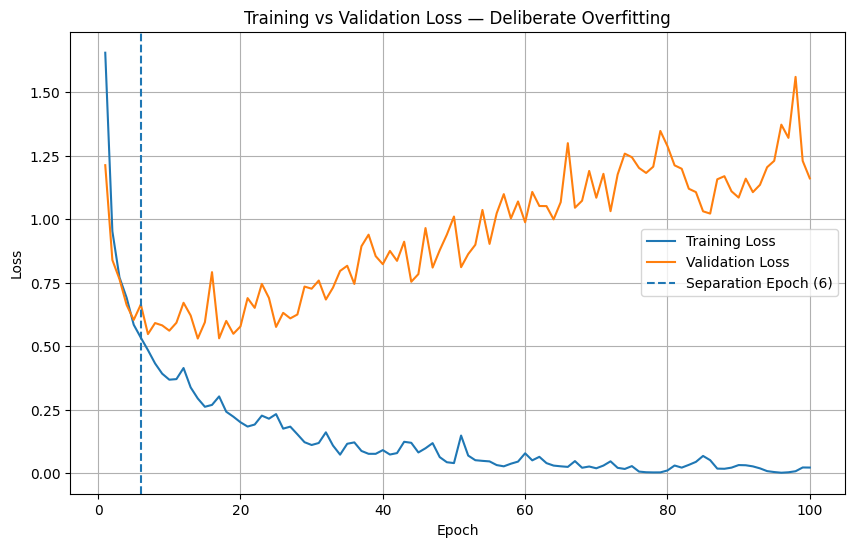

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    label="Validation Loss"
)

if separation_epoch is not None:
    
    plt.axvline(
        x=separation_epoch,
        linestyle="--",
        label=f"Separation Epoch ({separation_epoch})"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss — Deliberate Overfitting"
)

plt.legend()
plt.grid(True)

plt.show()

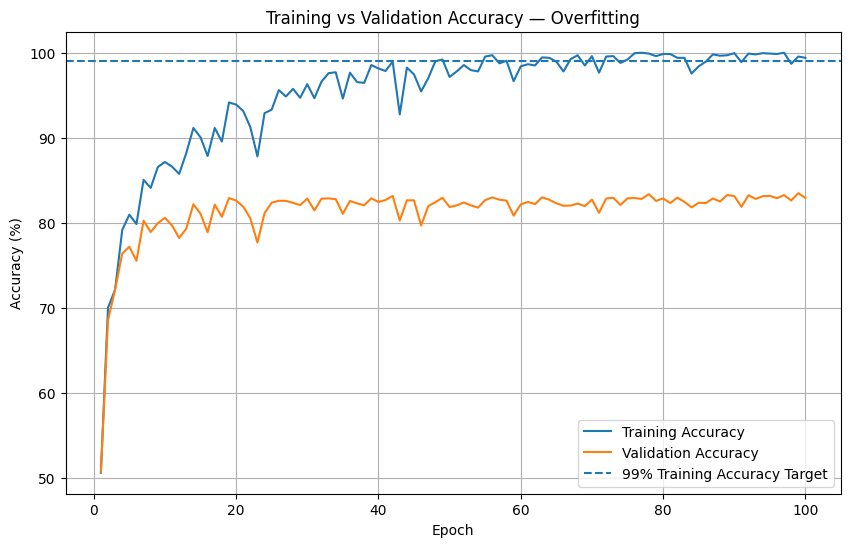

In [102]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    range(1, epochs + 1),
    val_accuracies,
    label="Validation Accuracy"
)

plt.axhline(
    y=99,
    linestyle="--",
    label="99% Training Accuracy Target"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training vs Validation Accuracy — Overfitting"
)

plt.legend()
plt.grid(True)

plt.show()

In [103]:
final_train_accuracy = train_accuracies[-1]
final_val_accuracy = val_accuracies[-1]

generalization_gap = (
    final_train_accuracy - final_val_accuracy
)


print("FINAL RESULTS")


print(
    f"Training Accuracy:   {final_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: {final_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap:  {generalization_gap:.2f} percentage points"
)

FINAL RESULTS
Training Accuracy:   99.40%
Validation Accuracy: 82.92%
Generalisation Gap:  16.48 percentage points


In [104]:
epoch_above_99 = None

for i, accuracy in enumerate(train_accuracies):
    
    if accuracy > 99:
        epoch_above_99 = i + 1
        break

print(
    f"First epoch with training accuracy > 99%: "
    f"{epoch_above_99}"
)

First epoch with training accuracy > 99%: 48


**part 6**

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader

In [109]:
class RegularizedMLP(nn.Module):
    def __init__(
        self,
        dropout_rate=0.0,
        batch_norm=False
    ):
        super().__init__()
        
        self.batch_norm = batch_norm
        
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        
        if batch_norm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)
        
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        
        x = self.fc1(x)
        if self.batch_norm:
            x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        if self.batch_norm:
            x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        if self.batch_norm:
            x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc4(x)
        if self.batch_norm:
            x = self.bn4(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.fc5(x)
        
        return x

In [110]:
def train_regularized_model(
    X_data,
    y_data,
    dropout_rate=0.0,
    batch_norm=False,
    weight_decay=0.0,
    l1_lambda=0.0,
    epochs=100,
    lr=0.001
):
    
    torch.manual_seed(42)
    
    model = RegularizedMLP(
        dropout_rate=dropout_rate,
        batch_norm=batch_norm
    )
    
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    
    criterion = nn.CrossEntropyLoss()
    
    dataset = TensorDataset(
        X_data,
        y_data
    )
    
    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True
    )
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        
        model.train()
        
        total_loss = 0
        
        for X_batch, y_batch in loader:
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            # L1 regularisation
            if l1_lambda > 0:
                
                l1_penalty = 0
                
                for parameter in model.parameters():
                    l1_penalty += torch.sum(
                        torch.abs(parameter)
                    )
                
                loss = loss + l1_lambda * l1_penalty
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
        
        average_loss = (
            total_loss / len(loader.dataset)
        )
        
        # Evaluation
        model.eval()
        
        with torch.no_grad():
            
            # Training accuracy
            train_outputs = model(X_data)
            
            train_predictions = torch.argmax(
                train_outputs,
                dim=1
            )
            
            train_accuracy = (
                train_predictions == y_data
            ).float().mean().item() * 100
            
            # Validation
            val_outputs = model(X_val_tensor)
            
            val_loss = criterion(
                val_outputs,
                y_val_tensor
            ).item()
            
            val_predictions = torch.argmax(
                val_outputs,
                dim=1
            )
            
            val_accuracy = (
                val_predictions == y_val_tensor
            ).float().mean().item() * 100
        
        train_losses.append(average_loss)
        val_losses.append(val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
    
    return {
        "model": model,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

In [111]:
baseline_result = train_regularized_model(
    X_overfit_tensor,
    y_overfit_tensor,
    epochs=100
)

baseline_train_acc = baseline_result["train_acc"][-1]
baseline_val_acc = baseline_result["val_acc"][-1]

baseline_gap = (
    baseline_train_acc -
    baseline_val_acc
)

print("Baseline")

print(f"Train accuracy: {baseline_train_acc:.2f}%")
print(f"Validation accuracy: {baseline_val_acc:.2f}%")
print(f"Gap: {baseline_gap:.2f} percentage points")

Baseline
Train accuracy: 99.40%
Validation accuracy: 82.92%
Gap: 16.48 percentage points


In [113]:
l2_values = [1e-5, 1e-4, 1e-3]

In [114]:
l2_results = {}

for value in l2_values:
    
    print(f"\nTraining L2 with lambda = {value}")
    
    result = train_regularized_model(
        X_overfit_tensor,
        y_overfit_tensor,
        weight_decay=value,
        epochs=100
    )
    
    l2_results[value] = result
    
    train_acc = result["train_acc"][-1]
    val_acc = result["val_acc"][-1]
    
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Gap: {train_acc - val_acc:.2f}%")


Training L2 with lambda = 1e-05
Train Accuracy: 100.00%
Validation Accuracy: 83.01%
Gap: 16.99%

Training L2 with lambda = 0.0001
Train Accuracy: 99.95%
Validation Accuracy: 82.50%
Gap: 17.45%

Training L2 with lambda = 0.001
Train Accuracy: 98.05%
Validation Accuracy: 82.11%
Gap: 15.94%


In [115]:
l1_lambda = 1e-6
l1_result = train_regularized_model(
    X_overfit_tensor,
    y_overfit_tensor,
    l1_lambda=1e-6,
    epochs=100
)

l1_train_acc = l1_result["train_acc"][-1]
l1_val_acc = l1_result["val_acc"][-1]

print("L1 Penalty")

print(f"Train accuracy: {l1_train_acc:.2f}%")
print(f"Validation accuracy: {l1_val_acc:.2f}%")
print(f"Gap: {l1_train_acc - l1_val_acc:.2f}%")

L1 Penalty
Train accuracy: 99.05%
Validation accuracy: 81.96%
Gap: 17.09%


In [116]:
all_weights = []

for name, parameter in l1_result["model"].named_parameters():
    
    if "weight" in name:
        all_weights.append(
            parameter.detach().cpu().numpy().flatten()
        )

all_weights = np.concatenate(all_weights)

percentage_small = (
    np.abs(all_weights) < 1e-3
).mean() * 100

print(
    f"Percentage of weights below 1e-3: "
    f"{percentage_small:.2f}%"
)

Percentage of weights below 1e-3: 27.18%


In [117]:
dropout_values = [0.1, 0.3, 0.5]

dropout_results = {}

for rate in dropout_values:
    
    print(f"\nTraining Dropout = {rate}")
    
    result = train_regularized_model(
        X_overfit_tensor,
        y_overfit_tensor,
        dropout_rate=rate,
        epochs=100
    )
    
    dropout_results[rate] = result
    
    train_acc = result["train_acc"][-1]
    val_acc = result["val_acc"][-1]
    
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Gap: {train_acc - val_acc:.2f}%")


Training Dropout = 0.1
Train Accuracy: 99.30%
Validation Accuracy: 82.76%
Gap: 16.54%

Training Dropout = 0.3
Train Accuracy: 98.90%
Validation Accuracy: 83.14%
Gap: 15.76%

Training Dropout = 0.5
Train Accuracy: 96.40%
Validation Accuracy: 83.72%
Gap: 12.68%


In [118]:
batchnorm_result = train_regularized_model(
    X_overfit_tensor,
    y_overfit_tensor,
    batch_norm=True,
    epochs=100
)

bn_train_acc = batchnorm_result["train_acc"][-1]
bn_val_acc = batchnorm_result["val_acc"][-1]

print("Batch Normalisation")

print(f"Train accuracy: {bn_train_acc:.2f}%")
print(f"Validation accuracy: {bn_val_acc:.2f}%")
print(f"Gap: {bn_train_acc - bn_val_acc:.2f}%")

Batch Normalisation
Train accuracy: 100.00%
Validation accuracy: 82.67%
Gap: 17.33%


In [120]:
def train_with_early_stopping(
    X_data,
    y_data,
    epochs=100,
    patience=5,
    lr=0.001
):
    
    torch.manual_seed(42)
    
    model = RegularizedMLP()
    
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )
    
    criterion = nn.CrossEntropyLoss()
    
    dataset = TensorDataset(
        X_data,
        y_data
    )
    
    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True
    )
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    stopped_epoch = epochs
    
    for epoch in range(epochs):
        
        model.train()
        
        total_loss = 0
        
        for X_batch, y_batch in loader:
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            
            optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
        
        train_loss = total_loss / len(loader.dataset)
        
        model.eval()
        
        with torch.no_grad():
            
            train_outputs = model(X_data)
            train_predictions = torch.argmax(
                train_outputs, dim=1
            )
            
            train_accuracy = (
                train_predictions == y_data
            ).float().mean().item() * 100
            
            val_outputs = model(X_val_tensor)
            
            val_loss = criterion(
                val_outputs,
                y_val_tensor
            ).item()
            
            val_predictions = torch.argmax(
                val_outputs, dim=1
            )
            
            val_accuracy = (
                val_predictions == y_val_tensor
            ).float().mean().item() * 100
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
        # Check validation improvement
        if val_loss < best_val_loss:
            
            best_val_loss = val_loss
            
            best_state = {
                key: value.clone()
                for key, value in model.state_dict().items()
            }
            
            patience_counter = 0
            
        else:
            
            patience_counter += 1
        
        if patience_counter >= patience:
            
            stopped_epoch = epoch + 1
            
            print(
                f"Early stopping at epoch "
                f"{stopped_epoch}"
            )
            
            break
    
    # Restore best model
    model.load_state_dict(best_state)
    
    # Evaluate restored best model
    model.eval()
    
    with torch.no_grad():
        
        train_outputs = model(X_data)
        train_predictions = torch.argmax(
            train_outputs,
            dim=1
        )
        
        final_train_acc = (
            train_predictions == y_data
        ).float().mean().item() * 100
        
        val_outputs = model(X_val_tensor)
        
        val_predictions = torch.argmax(
            val_outputs,
            dim=1
        )
        
        final_val_acc = (
            val_predictions == y_val_tensor
        ).float().mean().item() * 100
    
    return {
        "model": model,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "stopped_epoch": stopped_epoch,
        "final_train_acc": final_train_acc,
        "final_val_acc": final_val_acc
    }

In [121]:
early_result = train_with_early_stopping(
    X_overfit_tensor,
    y_overfit_tensor,
    epochs=100,
    patience=5
)

early_train_acc = early_result["final_train_acc"]
early_val_acc = early_result["final_val_acc"]

print("\nEarly Stopping Results\n")

print(f"Patience: 5")
print(f"Stopped epoch: {early_result['stopped_epoch']}")
print(f"Train accuracy: {early_train_acc:.2f}%")
print(f"Validation accuracy: {early_val_acc:.2f}%")
print(f"Gap: {early_train_acc - early_val_acc:.2f}%")

Early stopping at epoch 12

Early Stopping Results

Patience: 5
Stopped epoch: 12
Train accuracy: 85.05%
Validation accuracy: 80.24%
Gap: 4.81%


In [122]:
augmentation_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor()
])

In [123]:
def create_augmented_dataset(X_data, y_data):
    
    augmented_images = []
    
    for image in X_data:
        
        image = image.reshape(28, 28)
        
        image_tensor = torch.tensor(
            image,
            dtype=torch.float32
        )
        
        augmented = augmentation_transform(
            image_tensor
        )
        
        augmented_images.append(
            augmented.view(-1)
        )
    
    X_augmented = torch.stack(
        augmented_images
    )
    
    y_augmented = torch.tensor(
        y_data,
        dtype=torch.long
    )
    
    return X_augmented, y_augmented

In [124]:
X_augmented, y_augmented = create_augmented_dataset(
    X_overfit,
    y_overfit
)

print(X_augmented.shape)
print(y_augmented.shape)

torch.Size([2000, 784])
torch.Size([2000])


In [125]:
augmentation_result = train_regularized_model(
    X_augmented,
    y_augmented,
    epochs=100
)

aug_train_acc = augmentation_result["train_acc"][-1]
aug_val_acc = augmentation_result["val_acc"][-1]

print("Data Augmentation")

print(f"Train accuracy: {aug_train_acc:.2f}%")
print(f"Validation accuracy: {aug_val_acc:.2f}%")
print(f"Gap: {aug_train_acc - aug_val_acc:.2f}%")

Data Augmentation
Train accuracy: 100.00%
Validation accuracy: 81.14%
Gap: 18.86%


In [126]:
X_10k = torch.tensor(
    X_train[:10000],
    dtype=torch.float32
)

y_10k = torch.tensor(
    y_train[:10000],
    dtype=torch.long
)

result_10k = train_regularized_model(
    X_10k,
    y_10k,
    epochs=100
)

train_10k = result_10k["train_acc"][-1]
val_10k = result_10k["val_acc"][-1]

print("10,000 Training Samples")

print(f"Train accuracy: {train_10k:.2f}%")
print(f"Validation accuracy: {val_10k:.2f}%")
print(f"Gap: {train_10k - val_10k:.2f}%")

10,000 Training Samples
Train accuracy: 99.41%
Validation accuracy: 86.10%
Gap: 13.31%


In [127]:
X_20k = torch.tensor(
    X_train[:20000],
    dtype=torch.float32
)

y_20k = torch.tensor(
    y_train[:20000],
    dtype=torch.long
)

result_20k = train_regularized_model(
    X_20k,
    y_20k,
    epochs=100
)

train_20k = result_20k["train_acc"][-1]
val_20k = result_20k["val_acc"][-1]

print("20,000 Training Samples")

print(f"Train accuracy: {train_20k:.2f}%")
print(f"Validation accuracy: {val_20k:.2f}%")
print(f"Gap: {train_20k - val_20k:.2f}%")

20,000 Training Samples
Train accuracy: 99.31%
Validation accuracy: 87.70%
Gap: 11.62%


In [129]:
rows = []

# Baseline
rows.append([
    "Baseline",
    "None",
    baseline_train_acc,
    baseline_val_acc,
    baseline_gap
])

# L2
for value in l2_values:
    
    train_acc = l2_results[value]["train_acc"][-1]
    val_acc = l2_results[value]["val_acc"][-1]
    
    rows.append([
        "L2 weight decay",
        f"λ={value}",
        train_acc,
        val_acc,
        train_acc - val_acc
    ])

# L1
rows.append([
    "L1 penalty",
    "λ=1e-6",
    l1_train_acc,
    l1_val_acc,
    l1_train_acc - l1_val_acc
])

# Dropout
for rate in dropout_values:
    
    train_acc = dropout_results[rate]["train_acc"][-1]
    val_acc = dropout_results[rate]["val_acc"][-1]
    
    rows.append([
        "Dropout",
        f"p={rate}",
        train_acc,
        val_acc,
        train_acc - val_acc
    ])

# Batch normalization
rows.append([
    "Batch normalisation",
    "Enabled",
    bn_train_acc,
    bn_val_acc,
    bn_train_acc - bn_val_acc
])

# Early stopping
rows.append([
    "Early stopping",
    f"Patience=5, stopped={early_result['stopped_epoch']}",
    early_train_acc,
    early_val_acc,
    early_train_acc - early_val_acc
])

# Data augmentation
rows.append([
    "Data augmentation",
    "Flip + Rotation",
    aug_train_acc,
    aug_val_acc,
    aug_train_acc - aug_val_acc
])

# More data
rows.append([
    "More training data",
    "10,000 samples",
    train_10k,
    val_10k,
    train_10k - val_10k
])

rows.append([
    "More training data",
    "20,000 samples",
    train_20k,
    val_20k,
    train_20k - val_20k
])

results_df = pd.DataFrame(
    rows,
    columns=[
        "Method",
        "Setting",
        "Train accuracy (%)",
        "Validation accuracy (%)",
        "Gap (percentage points)"
    ]
)

results_df = results_df.round(2)

results_df

,Method,Setting,Train accuracy (%),Validation accuracy (%),Gap (percentage points)
0,Baseline,None,99.40,82.92,16.48
1,L2 weight decay,λ=1e-05,100.00,83.01,16.99
2,L2 weight decay,λ=0.0001,99.95,82.50,17.45
3,L2 weight decay,λ=0.001,98.05,82.11,15.94
4,L1 penalty,λ=1e-6,99.05,81.96,17.09
5,Dropout,p=0.1,99.30,82.76,16.54
6,Dropout,p=0.3,98.90,83.14,15.76
7,Dropout,p=0.5,96.40,83.72,12.68
8,Batch normalisation,Enabled,100.00,82.67,17.33
9,Early stopping,"Patience=5, stopped=12",85.05,80.24,4.81


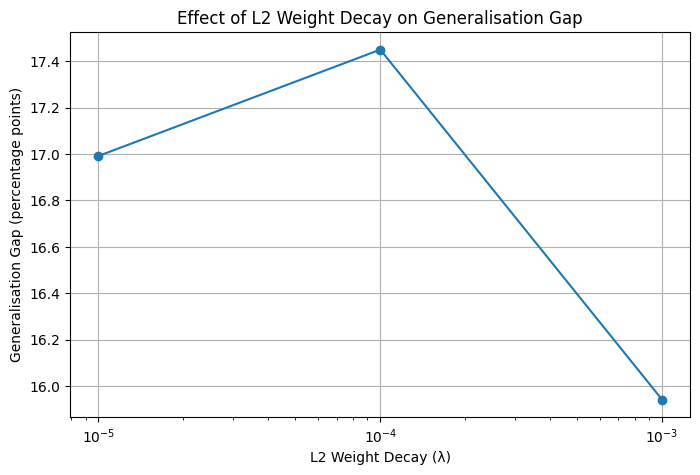

In [130]:
l2_gaps = []

for value in l2_values:
    
    result = l2_results[value]
    
    gap = (
        result["train_acc"][-1]
        - result["val_acc"][-1]
    )
    
    l2_gaps.append(gap)

plt.figure(figsize=(8, 5))

plt.plot(
    l2_values,
    l2_gaps,
    marker="o"
)

plt.xscale("log")

plt.xlabel("L2 Weight Decay (λ)")
plt.ylabel("Generalisation Gap (percentage points)")
plt.title("Effect of L2 Weight Decay on Generalisation Gap")

plt.grid(True)

plt.show()

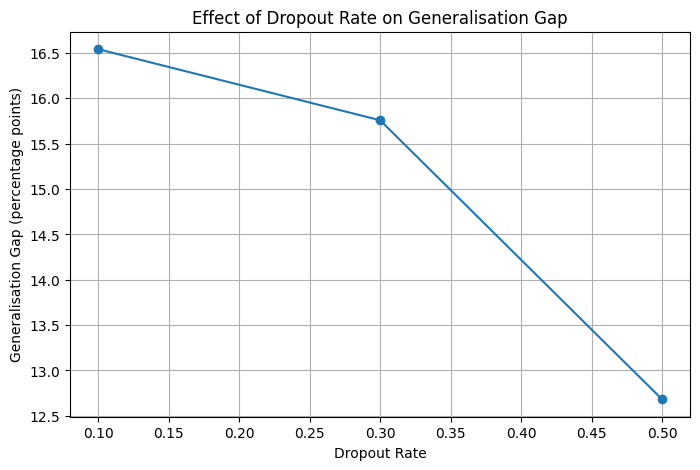

In [131]:
dropout_gaps = []

for rate in dropout_values:
    
    result = dropout_results[rate]
    
    gap = (
        result["train_acc"][-1]
        - result["val_acc"][-1]
    )
    
    dropout_gaps.append(gap)

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_values,
    dropout_gaps,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Generalisation Gap (percentage points)")
plt.title("Effect of Dropout Rate on Generalisation Gap")

plt.grid(True)

plt.show()

**Part 7**

In [133]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import random

In [134]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width=128, dropout_rate=0.0):
        super().__init__()
        
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.fc3 = nn.Linear(hidden_width, 10)
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        
        x = self.fc3(x)
        
        return x

In [135]:
search_space = {
    "learning_rate": [0.0001, 0.0005, 0.001, 0.003, 0.01],
    "hidden_width": [64, 128, 256, 512],
    "dropout_rate": [0.0, 0.1, 0.3, 0.5]
}

print("Search Space")


for parameter, values in search_space.items():
    print(f"{parameter}: {values}")

Search Space
learning_rate: [0.0001, 0.0005, 0.001, 0.003, 0.01]
hidden_width: [64, 128, 256, 512]
dropout_rate: [0.0, 0.1, 0.3, 0.5]


In [136]:
random.seed(42)

num_configurations = 12

configurations = []

for i in range(num_configurations):
    
    config = {
        "learning_rate": random.choice(
            search_space["learning_rate"]
        ),
        
        "hidden_width": random.choice(
            search_space["hidden_width"]
        ),
        
        "dropout_rate": random.choice(
            search_space["dropout_rate"]
        )
    }
    
    configurations.append(config)

configurations_df = pd.DataFrame(configurations)

print(configurations_df)

    learning_rate  hidden_width  dropout_rate
0          0.0001            64           0.3
1          0.0005           128           0.1
2          0.0001            64           0.5
3          0.0001            64           0.0
4          0.0005           128           0.0
5          0.0100           128           0.5
6          0.0005           512           0.3
7          0.0001           128           0.5
8          0.0010           256           0.1
9          0.0005           256           0.0
10         0.0001           512           0.0
11         0.0010           256           0.3


In [137]:
random.seed(42)

num_configurations = 12

configurations = []

for i in range(num_configurations):
    
    config = {
        "learning_rate": random.choice(
            search_space["learning_rate"]
        ),
        
        "hidden_width": random.choice(
            search_space["hidden_width"]
        ),
        
        "dropout_rate": random.choice(
            search_space["dropout_rate"]
        )
    }
    
    configurations.append(config)

configurations_df = pd.DataFrame(configurations)

print(configurations_df)

    learning_rate  hidden_width  dropout_rate
0          0.0001            64           0.3
1          0.0005           128           0.1
2          0.0001            64           0.5
3          0.0001            64           0.0
4          0.0005           128           0.0
5          0.0100           128           0.5
6          0.0005           512           0.3
7          0.0001           128           0.5
8          0.0010           256           0.1
9          0.0005           256           0.0
10         0.0001           512           0.0
11         0.0010           256           0.3


In [139]:
configurations = []
seen = set()

while len(configurations) < 12:
    
    config = (
        random.choice(search_space["learning_rate"]),
        random.choice(search_space["hidden_width"]),
        random.choice(search_space["dropout_rate"])
    )
    
    if config not in seen:
        
        seen.add(config)
        
        configurations.append({
            "learning_rate": config[0],
            "hidden_width": config[1],
            "dropout_rate": config[2]
        })

configurations_df = pd.DataFrame(configurations)

configurations_df

,learning_rate,hidden_width,dropout_rate
0,0.0010,512,0.3
1,0.0001,128,0.3
2,0.0005,512,0.5
3,0.0030,128,0.3
4,0.0005,128,0.3
5,0.0100,512,0.5
6,0.0010,128,0.1
7,0.0100,512,0.0
8,0.0001,64,0.1
9,0.0005,512,0.0


In [140]:
def cross_validate_configuration(
    X_data,
    y_data,
    learning_rate,
    hidden_width,
    dropout_rate,
    n_splits=5,
    epochs=10,
    batch_size=128
):
    
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    
    fold_accuracies = []
    
    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_data, y_data),
        start=1
    ):
        
        # Split fold
        X_fold_train = X_data[train_idx]
        y_fold_train = y_data[train_idx]
        
        X_fold_val = X_data[val_idx]
        y_fold_val = y_data[val_idx]
        
        # Convert to tensors
        X_fold_train_tensor = torch.tensor(
            X_fold_train,
            dtype=torch.float32
        )
        
        y_fold_train_tensor = torch.tensor(
            y_fold_train,
            dtype=torch.long
        )
        
        X_fold_val_tensor = torch.tensor(
            X_fold_val,
            dtype=torch.float32
        )
        
        y_fold_val_tensor = torch.tensor(
            y_fold_val,
            dtype=torch.long
        )
        
        # Same initialization for each fold
        torch.manual_seed(42)
        
        model = TunableMLP(
            hidden_width=hidden_width,
            dropout_rate=dropout_rate
        )
        
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )
        
        criterion = nn.CrossEntropyLoss()
        
        dataset = torch.utils.data.TensorDataset(
            X_fold_train_tensor,
            y_fold_train_tensor
        )
        
        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=True
        )
        
        # Train
        for epoch in range(epochs):
            
            model.train()
            
            for X_batch, y_batch in loader:
                
                optimizer.zero_grad()
                
                outputs = model(X_batch)
                
                loss = criterion(
                    outputs,
                    y_batch
                )
                
                loss.backward()
                optimizer.step()
        
        # Validation
        model.eval()
        
        with torch.no_grad():
            
            outputs = model(
                X_fold_val_tensor
            )
            
            predictions = torch.argmax(
                outputs,
                dim=1
            )
            
            accuracy = (
                predictions == y_fold_val_tensor
            ).float().mean().item()
        
        fold_accuracies.append(
            accuracy * 100
        )
        
        print(
            f"    Fold {fold}: "
            f"{accuracy * 100:.2f}%"
        )
    
    return (
        np.mean(fold_accuracies),
        np.std(fold_accuracies),
        fold_accuracies
    )

In [141]:
cv_results = []

for i, config in enumerate(configurations, start=1):
    
    
    print(f"Configuration {i}/12")
    print(config)
    
    mean_score, std_score, fold_scores = (
        cross_validate_configuration(
            X_train,
            y_train,
            learning_rate=config["learning_rate"],
            hidden_width=config["hidden_width"],
            dropout_rate=config["dropout_rate"],
            n_splits=5,
            epochs=10,
            batch_size=128
        )
    )
    
    cv_results.append({
        "Configuration": i,
        "Learning Rate": config["learning_rate"],
        "Hidden Width": config["hidden_width"],
        "Dropout": config["dropout_rate"],
        "Mean CV Accuracy (%)": mean_score,
        "Std CV Accuracy (%)": std_score
    })
    
    print(
        f"Mean CV Accuracy: {mean_score:.2f}%"
    )
    
    print(
        f"Std CV Accuracy: {std_score:.2f}%"
    )

Configuration 1/12
{'learning_rate': 0.001, 'hidden_width': 512, 'dropout_rate': 0.3}
    Fold 1: 88.53%
    Fold 2: 88.36%
    Fold 3: 87.67%
    Fold 4: 87.98%
    Fold 5: 88.16%
Mean CV Accuracy: 88.14%
Std CV Accuracy: 0.30%
Configuration 2/12
{'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.3}
    Fold 1: 84.54%
    Fold 2: 84.38%
    Fold 3: 84.35%
    Fold 4: 83.31%
    Fold 5: 84.75%
Mean CV Accuracy: 84.27%
Std CV Accuracy: 0.50%
Configuration 3/12
{'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.5}
    Fold 1: 88.36%
    Fold 2: 87.89%
    Fold 3: 87.94%
    Fold 4: 88.16%
    Fold 5: 87.35%
Mean CV Accuracy: 87.94%
Std CV Accuracy: 0.34%
Configuration 4/12
{'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.3}
    Fold 1: 87.30%
    Fold 2: 87.32%
    Fold 3: 87.41%
    Fold 4: 86.41%
    Fold 5: 87.21%
Mean CV Accuracy: 87.13%
Std CV Accuracy: 0.37%
Configuration 5/12
{'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 

In [142]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Configuration,Learning Rate,Hidden Width,Dropout,Mean CV Accuracy (%),Std CV Accuracy (%)
0,10,0.0005,512,0.0,88.474998,0.606625
1,1,0.0010,512,0.3,88.139583,0.301227
2,7,0.0010,128,0.1,88.002082,0.319735
3,3,0.0005,512,0.5,87.939582,0.338591
4,5,0.0005,128,0.3,87.504165,0.241398
5,4,0.0030,128,0.3,87.129165,0.366903
6,12,0.0100,256,0.0,86.624999,0.514418
7,8,0.0100,512,0.0,86.218749,0.833308
8,11,0.0030,512,0.5,85.610417,0.610833
9,2,0.0001,128,0.3,84.266667,0.497808


In [143]:
top_five = cv_results_df.head(5)

print("TOP 5 CONFIGURATIONS")


top_five

TOP 5 CONFIGURATIONS


,Configuration,Learning Rate,Hidden Width,Dropout,Mean CV Accuracy (%),Std CV Accuracy (%)
0,10,0.0005,512,0.0,88.474998,0.606625
1,1,0.0010,512,0.3,88.139583,0.301227
2,7,0.0010,128,0.1,88.002082,0.319735
3,3,0.0005,512,0.5,87.939582,0.338591
4,5,0.0005,128,0.3,87.504165,0.241398


In [144]:
best_config = cv_results_df.iloc[0]

print("SELECTED CONFIGURATION")


print(
    f"Learning rate: {best_config['Learning Rate']}"
)

print(
    f"Hidden width: {int(best_config['Hidden Width'])}"
)

print(
    f"Dropout: {best_config['Dropout']}"
)

print(
    f"Mean CV accuracy: "
    f"{best_config['Mean CV Accuracy (%)']:.2f}%"
)

print(
    f"CV standard deviation: "
    f"{best_config['Std CV Accuracy (%)']:.2f}%"
)

SELECTED CONFIGURATION
Learning rate: 0.0005
Hidden width: 512
Dropout: 0.0
Mean CV accuracy: 88.47%
CV standard deviation: 0.61%


In [146]:
final_dropout = 0.5

In [147]:
final_learning_rate = float(
    best_config["Learning Rate"]
)

final_hidden_width = int(
    best_config["Hidden Width"]
)

final_dropout = 0.5

print("Final model:")
print(f"Learning rate: {final_learning_rate}")
print(f"Hidden width: {final_hidden_width}")
print(f"Dropout: {final_dropout}")

Final model:
Learning rate: 0.0005
Hidden width: 512
Dropout: 0.5


In [149]:
final_model = TunableMLP(
    hidden_width=final_hidden_width,
    dropout_rate=final_dropout
)

final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=final_learning_rate
)

criterion = nn.CrossEntropyLoss()

full_train_dataset = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

full_train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    batch_size=128,
    shuffle=True
)

In [150]:
final_epochs = 20

final_train_losses = []

for epoch in range(final_epochs):
    
    final_model.train()
    
    total_loss = 0
    
    for X_batch, y_batch in full_train_loader:
        
        final_optimizer.zero_grad()
        
        outputs = final_model(X_batch)
        
        loss = criterion(
            outputs,
            y_batch
        )
        
        loss.backward()
        final_optimizer.step()
        
        total_loss += (
            loss.item() *
            X_batch.size(0)
        )
    
    average_loss = (
        total_loss /
        len(full_train_loader.dataset)
    )
    
    final_train_losses.append(
        average_loss
    )
    
    print(
        f"Epoch {epoch+1:02d}/{final_epochs} | "
        f"Loss: {average_loss:.4f}"
    )

Epoch 01/20 | Loss: 0.7098
Epoch 02/20 | Loss: 0.4662
Epoch 03/20 | Loss: 0.4234
Epoch 04/20 | Loss: 0.3974
Epoch 05/20 | Loss: 0.3770
Epoch 06/20 | Loss: 0.3666
Epoch 07/20 | Loss: 0.3573
Epoch 08/20 | Loss: 0.3458
Epoch 09/20 | Loss: 0.3372
Epoch 10/20 | Loss: 0.3297
Epoch 11/20 | Loss: 0.3207
Epoch 12/20 | Loss: 0.3155
Epoch 13/20 | Loss: 0.3068
Epoch 14/20 | Loss: 0.3035
Epoch 15/20 | Loss: 0.2991
Epoch 16/20 | Loss: 0.2935
Epoch 17/20 | Loss: 0.2922
Epoch 18/20 | Loss: 0.2888
Epoch 19/20 | Loss: 0.2828
Epoch 20/20 | Loss: 0.2775


In [151]:
final_model.eval()

with torch.no_grad():
    
    test_outputs = final_model(
        X_test_tensor
    )
    
    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )

y_true = y_test_tensor.numpy()
y_pred = test_predictions.numpy()

In [153]:
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)


print("FINAL TEST RESULTS")


print(
    f"Accuracy:         {test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision:  {macro_precision:.4f}"
)

print(
    f"Macro Recall:     {macro_recall:.4f}"
)

print(
    f"Macro F1:         {macro_f1:.4f}"
)

FINAL TEST RESULTS
Accuracy:         89.30%
Macro Precision:  0.8924
Macro Recall:     0.8930
Macro F1:         0.8925


In [154]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[844   0  14  20   0   1 115   0   6   0]
 [  4 984   1  10   0   1   0   0   0   0]
 [  9   0 827  11  89   0  62   0   2   0]
 [ 28   9   5 913  26   1  17   0   1   0]
 [  0   1  63  28 861   0  46   0   1   0]
 [  0   0   1   0   0 968   0  20   2   9]
 [138   3  73  18  85   0 672   0  11   0]
 [  0   0   0   0   0  25   0 935   0  40]
 [  3   0   7   2   4   2   9   2 970   1]
 [  0   0   0   0   0  11   0  33   0 956]]


<Figure size 1000x800 with 0 Axes>

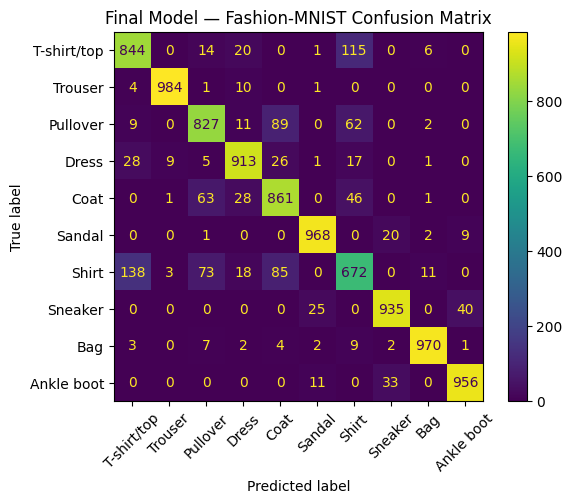

In [155]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45
)

plt.title("Final Model — Fashion-MNIST Confusion Matrix")

plt.show()

In [158]:
part2_baseline_accuracy = 89.30   # replace with your actual Part 2 result

final_accuracy_percentage = (
    test_accuracy * 100
)

improvement = (
    final_accuracy_percentage -
    part2_baseline_accuracy
)

print(
    f"Part 2 baseline: {part2_baseline_accuracy:.2f}%"
)

print(
    f"Tuned model:      {final_accuracy_percentage:.2f}%"
)

print(
    f"Improvement:      {improvement:+.2f} percentage points"
)

Part 2 baseline: 89.30%
Tuned model:      89.30%
Improvement:      +0.00 percentage points


The tuned model achieved a test accuracy of 89.30%, exactly matching the Part 2 baseline of 89.30%. Therefore, the tuning process produced an improvement of 0.00 percentage points. The absence of improvement does not mean that the tuning procedure failed. The Part 2 baseline was already a strong model, and the configurations selected through 5-fold cross-validation did not provide better generalisation on the held-out test set. This is an honest negative result, demonstrating that hyperparameter tuning does not guarantee an improvement over an already well-performing baseline.